# Алгоритм k ближайших соседей (k-nearest neighbors, k-NN)

Практическое занятие по дисциплине **«Статистические методы Data
Science»**, бакалавриат. Продолжительность — 80 минут. Язык
программирования — Python.

**Цель занятия.** Научиться применять метод k ближайших соседей к
задачам классификации и регрессии: обосновывать стандартизацию
признаков, подбирать число соседей $k$ по качеству на отложенной выборке
и интерпретировать метрики качества.

**Итоговый продукт.** Ноутбук с выполненными заданиями 1–3: обученные
модели, таблицы ошибок и метрик, график зависимости качества от $k$,
письменные выводы по каждому заданию.

## Теория

Раздел опирается на лекцию **«Кластерный анализ, метод k ближайших
соседей»**; ниже собрана теория метода в объёме, достаточном для
выполнения заданий.

**K-NN** — это алгоритм машинного обучения, используемый для
классификации и регрессии. Он основан на принципе, что объекты, похожие
друг на друга, вероятно, принадлежат к одному классу.

### Основные шаги метода

#### 1. Вычисление расстояний

Для каждого объекта тестовой выборки вычисляется расстояние до каждого
объекта обучающей выборки. Обычно используется евклидово расстояние, но
возможны и другие метрики, такие как манхэттенское расстояние или
другие, в зависимости от специфики задачи.

**Евклидово расстояние.** Евклидово расстояние между двумя точками
$\mathbf{x} = (x_1, x_2, \dots, x_n)$ и
$\mathbf{y} = (y_1, y_2, \dots, y_n)$ в $n$-мерном пространстве
определяется формулой:

$$
d(\mathbf{x}, \mathbf{y}) = \sqrt{ (x_1 - y_1)^2 + (x_2 - y_2)^2 + \dots + (x_n - y_n)^2 } = \sqrt{ \sum_{i=1}^{n} (x_i - y_i)^2 }
$$

**Манхэттенское расстояние** между теми же двумя точками определяется
как сумма модулей разностей соответствующих координат:

$$
d(\mathbf{x}, \mathbf{y}) = |x_1 - y_1| + |x_2 - y_2| + \dots + |x_n - y_n| = \sum_{i=1}^{n} |x_i - y_i|
$$

**Пояснения:**

- **Евклидово расстояние** измеряет «прямое» расстояние («по прямой»)
  между двумя точками в пространстве и соответствует длине отрезка,
  соединяющего эти точки.
- **Манхэттенское расстояние** (также известное как расстояние городских
  кварталов) измеряет расстояние, которое нужно пройти по осям
  координат, то есть суммарное расстояние вдоль осей.

В scikit-learn мера расстояния задаётся параметрами `metric` и `p`: при
$p = 2$ это евклидово расстояние, при $p = 1$ — манхэттенское.

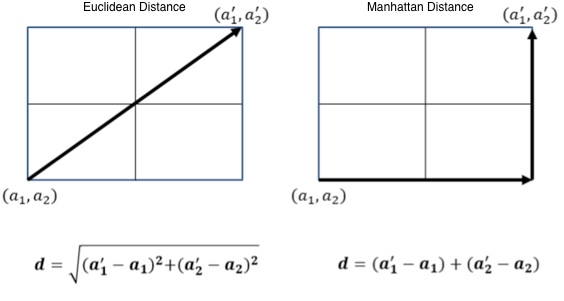

#### 2. Отбор k ближайших

После вычисления расстояний выбираются $k$ объектов из обучающей
выборки, которые находятся ближе всего к тестовому объекту. Значение $k$
— гиперпараметр, который влияет на точность модели. Небольшие значения
$k$ могут сделать модель чувствительной к шуму в данных, тогда как
большие значения $k$ могут сгладить решение, но увеличить вычислительные
затраты и потенциально привести к недообучению.

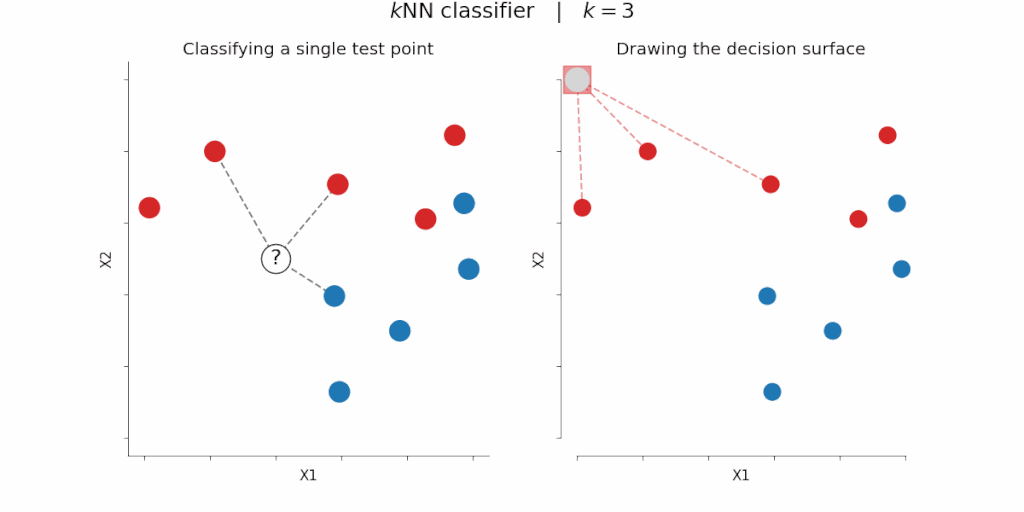

#### 3. Классификация и регрессия

В задаче классификации класс объекта определяется по большинству голосов
среди его $k$ ближайших соседей:

$$
\hat{y}(x) = \arg\max_{c} \sum_{x_i \in N_k(x)} \mathbb{I}[\,y_i = c\,]
$$

где $N_k(x)$ — множество $k$ ближайших к $x$ объектов обучающей выборки,
$y_i$ — известная метка класса $i$-го объекта, $\mathbb{I}[\cdot]$ —
индикатор, равный единице при истинном условии.

В задаче регрессии предсказание — это среднее или медианное значение
целевой переменной среди $k$ соседей.

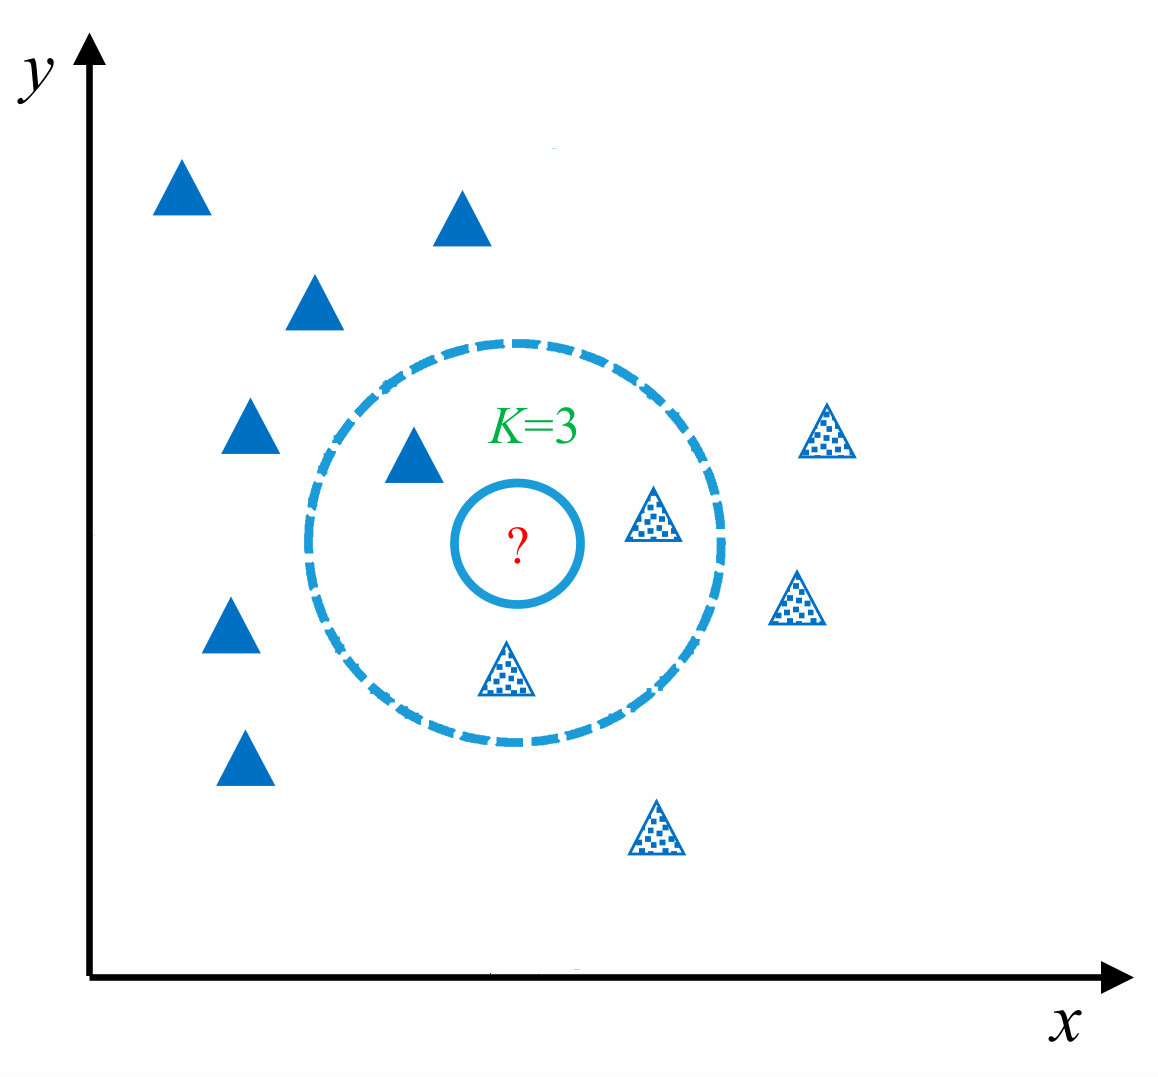

### Детали реализации

- **Обучение.** В отличие от других алгоритмов, k-NN не требует явного
  этапа обучения. Всё, что делает алгоритм, — сохраняет обучающие
  данные. Это делает его «ленивым» алгоритмом, так как все вычисления
  откладываются до момента предсказания.
- **Предсказание.** Когда требуется сделать предсказание для нового
  объекта, алгоритм:
  - вычисляет расстояния от нового объекта до всех объектов обучающего
    набора;
  - сортирует эти расстояния и выбирает $k$ объектов с наименьшими
    значениями;
  - применяет правило голосования (для классификации) или усреднения
    (для регрессии) среди выбранных $k$ соседей.

### Выбор числа соседей k

Выбор значения $k$ критически важен. Слишком маленькое $k$ может
привести к переобучению, когда модель слишком адаптируется к обучающим
данным, включая их шум. Слишком большое $k$ может привести к
недообучению, когда модель не сможет уловить сложные закономерности в
данных.

- Малое $k$ (например, 1): граница решения сложная, прогноз чувствителен
  к шуму и единичным ошибочным меткам.
- Большое $k$: граница сглаживается, локальные особенности теряются; при
  очень большом $k$ прогноз стремится к самому частому классу.
- Значение $k$ выбирают по качеству на отложенной выборке или по
  кросс-валидации, но не по качеству на обучающей выборке.

### Стандартизация признаков

Признаки стандартизуют, если они измерены в разных единицах: иначе
расстояние определяется самым крупномасштабным признаком, а остальные
почти не влияют на результат. Преобразование обучается **только на
обучающей части** и затем применяется к тестовой, иначе возникает утечка
данных.

### Подбор k по кросс-валидации

Чтобы подобрать оптимальное значение параметра $k$ в методе k ближайших
соседей с помощью кросс-валидации, выполняют следующие шаги.

1.  **Определение диапазона значений для k.** Задают набор возможных
    значений параметра $k$, которые нужно протестировать (например, от 1
    до 20).
2.  **Кросс-валидация для каждого значения k.**
    - **Разбиение данных.** Исходный набор данных делится на несколько
      подмножеств (фолдов), обычно используют 5 или 10 фолдов.
    - **Итерация по фолдам.** Для каждого значения $k$ и каждого фолда:
      - **Обучающая выборка.** Используются все фолды, кроме одного.
      - **Тестовая выборка.** Оставшийся фолд служит для проверки
        (валидации) модели.
      - **Обучение модели.** Строится модель k-NN с текущим значением
        $k$ на обучающей части.
      - **Оценка модели.** Модель проверяется на тестовом фолде,
        вычисляется метрика качества (например, доля верных ответов или
        F-мера).
3.  **Агрегация результатов.** Для каждого значения $k$ вычисляется
    среднее значение метрики качества по всем фолдам — это оценка
    качества модели при данном $k$.
4.  **Выбор оптимального k.** Сравниваются средние метрики для всех
    протестированных значений $k$ и выбирается то значение, при котором
    метрика качества максимальна (или минимальна, в зависимости от
    используемой метрики).

Кросс-валидация позволяет объективно оценить, как модель с разными
значениями $k$ будет обобщаться на новых данных. Это помогает избежать
переобучения (когда $k$ слишком мало) и недообучения (когда $k$ слишком
велико), подбирая такое значение $k$, при котором модель показывает
наилучшие результаты на независимых наборах данных. В scikit-learn для
этого служит функция `cross_val_score`.

### Метрика расстояния, сложность и недостатки метода

- **Метрика расстояния.** Выбор метрики должен основываться на природе
  данных и задачи. Евклидово расстояние хорошо работает для непрерывных
  данных, но для текстовых данных или данных с категориальными
  признаками могут быть более подходящими другие метрики.
- **Вычислительная сложность.** Хотя k-NN прост в реализации, он может
  быть вычислительно затратным для больших наборов данных, так как
  требует вычисления расстояний до каждого обучающего примера при каждом
  предсказании.
- **Преимущества и недостатки.** k-NN хорош для понимания интуиции
  машинного обучения, но его ленивый характер может быть как
  преимуществом (легкость обновления модели при добавлении новых
  данных), так и недостатком (высокие затраты на предсказание).
- **Недостатки метода k-NN:**
  - **Хранение данных:** необходимость хранения всех обучающих данных.
  - **Проклятие размерности:** в пространствах высокой размерности
    расстояния выравниваются, и ближайшие соседи перестают быть
    «близкими».
  - **Чувствительность:** к выбору метрики расстояния, к масштабу
    признаков и к предобработке данных, к выбору $k$ и к ошибкам в
    метках.

### Метрики оценивания

#### Доля правильных ответов (accuracy)

$$
\text{accuracy}(a, X) = \frac{1}{\ell} \sum_{i=1}^{\ell} [a(x_i) = y_i]
$$

Доля правильных ответов, или accuracy, — одна из наиболее простых и
распространённых метрик качества классификации. Она вычисляется как доля
объектов, которые были правильно классифицированы. Формально это среднее
значение индикаторной функции, которая равна 1, если предсказанный класс
совпадает с истинным, и 0 в противном случае.

> **Пример.** Если у нас есть 100 объектов и 95 из них были правильно
> классифицированы, то accuracy равна 0.95.

#### Таблица ошибок

|            | $y = 1$             | $y = 0$             |
|------------|---------------------|---------------------|
| $a(x) = 1$ | True Positive (TP)  | False Positive (FP) |
| $a(x) = 0$ | False Negative (FN) | True Negative (TN)  |

Таблица ошибок позволяет наглядно представить результаты работы
классификационной модели. Она состоит из четырёх частей:

1.  **True Positive (TP)** — количество объектов, которые модель верно
    классифицировала как принадлежащие положительному классу ($y = 1$) —
    модель правильно определила наличие классифицируемого признака.
2.  **False Positive (FP)** — количество объектов, которые модель
    ошибочно отнесла к положительному классу, хотя на самом деле они
    принадлежат отрицательному классу ($y = 0$). Это ошибки первого
    рода, когда модель «видит» признак там, где его нет.
3.  **False Negative (FN)** — количество объектов, которые модель
    ошибочно отнесла к отрицательному классу, хотя на самом деле они
    принадлежат положительному классу ($y = 1$). Это ошибки второго
    рода, когда модель «не видит» признак там, где он есть.
4.  **True Negative (TN)** — количество объектов, которые модель верно
    классифицировала как принадлежащие отрицательному классу ($y = 0$) —
    модель правильно определила отсутствие классифицируемого признака.

Использование таблицы ошибок позволяет глубже понять, как именно
работает классификационная модель, и выявить её слабые места, что
особенно важно при работе с несбалансированными данными. Таблица ошибок
служит основой для расчёта других метрик качества классификации, таких
как точность (precision), полнота (recall), F-мера и других.

#### Точность и полнота (precision и recall)

Точность и полнота — две ключевые метрики оценки качества
классификационных моделей, особенно там, где важно не только правильно
идентифицировать объекты положительного класса, но и не пропускать их.

**Точность** показывает, какая часть объектов, отнесённых моделью к
положительному классу, действительно принадлежит этому классу:

$$
\text{precision} = \frac{TP}{TP + FP}
$$

где $TP$ — количество истинно положительных классификаций, $FP$ —
количество ложноположительных классификаций.

**Полнота** отражает способность модели обнаруживать все реальные
объекты положительного класса:

$$
\text{recall} = \frac{TP}{TP + FN}
$$

где $FN$ — количество ложноотрицательных классификаций, то есть случаев,
когда модель не распознала положительный объект как таковой.

Между точностью и полнотой существует естественный компромисс: рост
одной метрики часто приводит к снижению другой. Важно найти баланс,
соответствующий целям конкретной задачи: в некоторых случаях
предпочтение отдаётся высокой точности, в других — высокой полноте. Для
совместной оценки точности и полноты используют F-меру — гармоническое
среднее этих двух метрик. В задачах с несколькими классами метрики
усредняют по классам (параметр `average='macro'` в scikit-learn).

## Предварительные знания

Для выполнения заданий нужно уметь:

- читать данные и работать с `pandas.DataFrame` (лекция «Первичная
  обработка данных. Оцифровка данных»);
- делить выборку на обучающую и тестовую (`train_test_split`) и
  понимать, зачем это делается (лекция «Дискриминантный анализ»);
- стандартизировать признаки (`StandardScaler`), понимая требование
  обучать преобразование только на обучающей части;
- считать метрики классификации (`accuracy_score`, `precision_score`,
  `recall_score`) и строить таблицу ошибок (лекция «Дискриминантный
  анализ»);
- оценивать модель кросс-валидацией (`cross_val_score`).

Если какой-то из пунктов забыт, вернитесь к соответствующему разделу
лекции: все эти инструменты уже встречались в курсе.

## Окружение и зависимости

Занятие выполняется в Jupyter-совместимой среде (JupyterLab, Jupyter
Notebook, VS Code, Positron) на интерпретаторе Python проекта.

| Пакет | Версия в проверенном окружении | Назначение |
|----|----|----|
| Python | 3.12 | интерпретатор |
| pandas | 3.0 | таблицы данных |
| numpy | 2.5 | числовые массивы, генерация векторов |
| scikit-learn | 1.9 | модели, метрики, разбиение выборки |
| matplotlib | 3.11 | графики |
| seaborn | 0.13 | диаграмма рассеяния в разобранном примере |

**Доступ в интернет не требуется:** данные лежат в каталоге `data/`,
изображения встроены в документ (исходные файлы — в `img/`).

**Как запускать.**

1.  Откройте файл `lab05_KNN.ipynb` в Jupyter-совместимой среде.
2.  Выполняйте ячейки сверху вниз на чистом ядре (Kernel → Restart & Run
    All); порядок ячеек важен, потому что задания используют переменные,
    созданные выше.
3.  Если вы работаете с исходным файлом `.qmd`, notebook создаётся
    командой `quarto render lab05_KNN.qmd --to ipynb`; в заголовке файла
    выполнение ячеек отключено, поэтому notebook получается без
    результатов и запускается вручную.

## Данные

| Набор | Где находится | Размер | Что предсказываем |
|------------------|------------------|------------------|------------------|
| `fraud.csv` | `data/fraud.csv` | 45 транзакций, 2 признака | признак мошеннической транзакции `fraud` (разобранный пример и подбор $k$) |
| Iris | встроен в scikit-learn (`load_iris`) | 150 объектов, 4 признака | сорт ириса, 3 класса (задание 1) |
| Wine | встроен в scikit-learn (`load_wine`) | 178 объектов, 13 признаков | сорт вина, 3 класса (задание 2) |
| Автомобили аукциона | `data/train_df.csv`, `data/test_df.csv` | 1663 и 1497 объектов, 19 числовых признаков | розничная цена `MMRCurrentRetailAveragePrice` (задание 3) |

Структура `fraud.csv`: `dist_from_home` — расстояние от дома до места
транзакции, `purchase_price_ratio` — отношение цены покупки к медианной
цене покупок пользователя, `fraud` — метка класса (1 — мошенническая
транзакция, 0 — обычная).

Наборы Iris и Wine поставляются вместе со scikit-learn, поэтому доступны
без загрузки из сети.

## Разобранный пример: выявление мошеннических транзакций

Ниже — полный цикл решения задачи классификации на небольшом наборе
данных: загрузка, визуализация, разбиение выборки, стандартизация,
обучение, таблица ошибок, метрики и подбор числа соседей. Этот пример —
образец для заданий; при его выполнении обращайте внимание на порядок
шагов.

### Шаг 1. Загрузка данных и знакомство с ними

In [ ]:
import os
from google.colab import files

os.makedirs('data', exist_ok=True)
for name in files.upload():
    os.replace(name, os.path.join('data', name))

In [ ]:
import pandas as pd

df = pd.read_csv('data/fraud.csv', header=0).dropna()
df.info()
print('Строк:', df.shape[0])
print('Доля мошеннических транзакций:', round(df['fraud'].mean(), 2))

`read_csv` читает таблицу, `dropna` удаляет строки с пропусками (в этом
файле пропусков нет, вызов оставлен как страховка).

**Документация:**
[`pandas.read_csv`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html),
[`DataFrame.dropna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html)

### Шаг 2. Визуализация

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=df, x='dist_from_home', y='purchase_price_ratio', hue='fraud')
plt.xlabel('Расстояние от дома')
plt.ylabel('Отношение цены к медианной')
plt.title('Мошеннические (1) и обычные (0) транзакции')
plt.show()

На диаграмме видно, насколько классы перекрываются. Чем сильнее
перекрытие, тем труднее задача.

**Документация:**
[`seaborn.scatterplot`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)

### Шаг 3. Разбиение на обучающую и тестовую выборки

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('fraud', axis=1)
y = df['fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)

print('Обучающая выборка:', X_train.shape, '| классы:', y_train.value_counts().to_dict())
print('Тестовая выборка:', X_test.shape, '| классы:', y_test.value_counts().to_dict())

Параметр `random_state` фиксирует разбиение, чтобы результат
воспроизводился. Параметр `stratify=y` сохраняет доли классов в обеих
частях, что важно при малом размере выборки. Без фиксации `random_state`
метрики будут меняться от запуска к запуску.

**Документация:**
[`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

### Шаг 4. Стандартизация признаков

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Средние по обучающей выборке:', scaler.mean_.round(3))
print('Стандартные отклонения:', scaler.scale_.round(3))

`fit_transform` вычисляет среднее и стандартное отклонение **по
обучающей выборке** и сразу преобразует её. К тестовой выборке
применяется только `transform` — с теми же параметрами. Если
стандартизовать все данные до разбиения, информация о тестовой части
попадёт в преобразование: это утечка данных.

**Документация:**
[`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

### Шаг 5. Обучение модели при k = 3 и предсказание

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

**Документация:**
[`KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

### Шаг 6. Таблица ошибок и метрики

In [ ]:
pd.crosstab(y_test, y_pred, rownames=['Истинные'], colnames=['Предсказание'], margins=True)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print('Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print('Precision:', round(precision_score(y_test, y_pred), 3))
print('Recall:', round(recall_score(y_test, y_pred), 3))

В строке `All` таблицы ошибок — сколько объектов каждого класса было в
тестовой выборке, в столбце `All` — сколько объектов модель отнесла к
каждому классу.

**Документация:**
[`pandas.crosstab`](https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html),
[`accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html),
[`precision_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html),
[`recall_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)

### Шаг 7. Подбор числа соседей по кросс-валидации

In [ ]:
from sklearn.model_selection import cross_val_score

k_range = list(range(1, 21))
k_scores = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

best_k = k_range[k_scores.index(max(k_scores))]
print('Оптимальное k по кросс-валидации:', best_k, '| средняя точность:', round(max(k_scores), 3))

In [ ]:
plt.plot(k_range, k_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'лучшее k = {best_k}')
plt.xlabel('Число соседей k')
plt.ylabel('Средняя точность при кросс-валидации')
plt.legend()
plt.show()

`cross_val_score` обучает модель на четырёх частях обучающей выборки и
проверяет на пятой, затем усредняет результат по пяти разбиениям.
Верхняя граница диапазона $k$ ограничена: на фолде обучается примерно
$31 \cdot 4 / 5 \approx 25$ объектов, поэтому при $k \ge 25$ часть
фолдов не может обучиться и оценка становится неопределённой (`nan`).

**Документация:**
[`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)

### Шаг 8. Итоговая модель и проверка на тестовой выборке

In [ ]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_best = knn_best.predict(X_test_scaled)

print('Accuracy:', round(accuracy_score(y_test, y_pred_best), 3))
print('Precision:', round(precision_score(y_test, y_pred_best), 3))
print('Recall:', round(recall_score(y_test, y_pred_best), 3))

**Что здесь важно заметить.** В этом примере всего 14 объектов в
тестовой выборке, поэтому один объект меняет accuracy примерно на 7
процентных пунктов: разница между значениями метрик при разных $k$ может
быть следствием случайности, а не реального превосходства одной модели.
На малых выборках оценку по кросс-валидации нужно сопоставлять с оценкой
на тестовой выборке, а не доверять ей слепо.

## Задание 1. Классификация сортов ириса

**Цель.** Выполнить полный цикл обучения k-NN по образцу разобранного
примера и интерпретировать таблицу ошибок.

**Исходные данные.** Встроенный набор `load_iris` (150 объектов, 4
признака: длина и ширина чашелистика и лепестка, 3 класса).

**Что сделать.**

1.  Разделите данные на обучающую и тестовую выборки: `test_size=0.3`,
    `random_state=0`, `stratify=y`.
2.  Стандартизируйте признаки, обучив преобразование только на обучающей
    части.
3.  Обучите `KNeighborsClassifier` при `k=5` и получите предсказания для
    тестовой выборки.
4.  Постройте таблицу ошибок с итогами по строкам и столбцам.
5.  Посчитайте `accuracy_score`, а также `precision_score` и
    `recall_score` с `average='macro'`.
6.  Ответьте письменно: какой класс распознаётся хуже остальных, с каким
    классом его путают и почему это ожидаемо, если сравнить диапазоны
    значений признаков отдельно по каждому классу (например,
    `X[y == 1].min(axis=0)` и `X[y == 1].max(axis=0)`)?

**Ограничения.** Число соседей в этом задании не подбирается — оно
фиксировано ($k = 5$); подбор выполняется в задании 2.

In [ ]:
# Задание 1, шаг 1: данные
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target

print('Признаки:', iris.feature_names)
print('Классы:', list(iris.target_names))
print('Форма данных:', X.shape)

In [ ]:
# Задание 1, шаг 2: разбиение и стандартизация
# TODO: разделите X и y на обучающую и тестовую части и стандартизируйте признаки.
# Не забудьте: scaler обучается только на обучающей части.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Обучающая выборка:', X_train.shape, '| тестовая выборка:', X_test.shape)

In [ ]:
# Задание 1, шаг 3: обучение модели при k = 5
# TODO: создайте KNeighborsClassifier(n_neighbors=5), обучите его и получите предсказания.

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

In [ ]:
# Задание 1, шаг 4: таблица ошибок и метрики
# TODO: выведите таблицу ошибок (pd.crosstab с margins=True)
# и три метрики: accuracy, precision с average='macro', recall с average='macro'.

# Письменный вывод (класс, с которым путают, объяснение) добавьте в ячейку markdown ниже.

display(pd.crosstab(pd.Series(iris.target_names[y_test], name='Истинные'),
                    pd.Series(iris.target_names[y_pred], name='Предсказание'), margins=True))

print('Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print('Precision (macro):', round(precision_score(y_test, y_pred, average='macro'), 3))
print('Recall (macro):', round(recall_score(y_test, y_pred, average='macro'), 3))
print('Recall по классам:', dict(zip(iris.target_names, recall_score(y_test, y_pred, average=None).round(3))))

for c in range(3):
    print(iris.target_names[c], '| min:', X[y == c].min(axis=0), '| max:', X[y == c].max(axis=0))

**Вывод по заданию 1.**

Setosa распознаётся без ошибок: по длине и ширине лепестка её диапазоны (1.0–1.9 и 0.1–0.6 см) не пересекаются с другими классами. Все ошибки в таблице — между versicolor и virginica; хуже распознаётся класс с наименьшим recall в выводе выше, и путают его со вторым из этой пары. Это ожидаемо: диапазоны признаков versicolor и virginica перекрываются (длина лепестка 3.0–5.1 и 4.5–6.9 см, ширина лепестка 1.0–1.8 и 1.4–2.5 см, длина чашелистика 4.9–7.0 и 4.9–7.9 см), поэтому объекты из зоны перекрытия имеют соседей обоих классов.

**Что должно получиться.**

- Таблица ошибок размера 3×3 с итогами: доля верных ответов 0.93–1.00,
  ошибки — только между двумя похожими классами.
- Три числа метрик с точностью до третьего знака.
- Письменный вывод о том, какие классы разделяются хуже.

**Критерии успешного выполнения.** Таблица ошибок заполнена, метрики
посчитаны, вывод опирается на числа, а не на общие слова. Если
`precision` и `recall` выдаёт предупреждение о многоклассовой задаче,
добавьте `average='macro'`.

**Типичные ошибки.** Стандартизация всех данных до разбиения (утечка);
пропущенный `average='macro'`; попытка судить о качестве модели по
точности на обучающей выборке.

**Документация:**
[`load_iris`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html),
[`KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

## Задание 2. Стандартизация и выбор числа соседей

**Цель.** Показать, как масштаб признаков и число соседей влияют на
качество k-NN, и выбрать $k$ по кросс-валидации.

**Исходные данные.** Встроенный набор `load_wine` (178 объектов, 13
признаков, измеренных в разных единицах: от долей единицы до тысяч).

**Что сделать.**

1.  Разделите данные: `test_size=0.3`, `random_state=0`, `stratify=y`.
2.  Обучите k-NN при `k=5` **без стандартизации** и **со
    стандартизацией**; сравните долю верных ответов на тестовой выборке.
    Объясните расхождение, опираясь на формулу евклидова расстояния и на
    диапазоны значений признаков (`wine.data.min(axis=0)`,
    `wine.data.max(axis=0)`).
3.  По стандартизованным данным постройте зависимость средней точности
    кросс-валидации (`cv=5`) от $k$ для $k = 1, \dots, 30$, отметьте
    лучшее $k$ на графике и обоснуйте выбор.
4.  Обучите итоговую модель с выбранным $k$ и посчитайте метрики на
    тестовой выборке.
5.  Сравните четыре варианта при `k=5`: комбинации `metric='euclidean'`
    / `metric='manhattan'` и `weights='uniform'` / `weights='distance'`.
    Сведите средние точности кросс-валидации в таблицу и сделайте вывод,
    какой вариант предпочтительнее на этих данных.

**Подсказка.** Параметр `weights='distance'` учитывает близость соседей:
вес соседа обратно пропорционален расстоянию.

**Ограничения.** Все сравнения проводите на одном и том же разбиении и
одной и той же схеме кросс-валидации, иначе числа несопоставимы.

In [ ]:
# Задание 2, шаг 1: данные
from sklearn.datasets import load_wine

wine = load_wine()
W, w = wine.data, wine.target

print('Признаков:', len(wine.feature_names), '| объектов:', W.shape[0])
print('Диапазоны признаков (минимум):', W.min(axis=0).round(2))
print('Диапазоны признаков (максимум):', W.max(axis=0).round(2))

In [ ]:
# Задание 2, шаг 2: сравнение без стандартизации и со стандартизацией
# TODO: разделите выборку, обучите два классификатора при k=5,
# выведите долю верных ответов на тестовой выборке для обоих вариантов.

W_train, W_test, w_train, w_test = train_test_split(
    W, w, test_size=0.3, random_state=0, stratify=w)

knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(W_train, w_train)
acc_raw = accuracy_score(w_test, knn_raw.predict(W_test))

scaler_w = StandardScaler()
W_train_scaled = scaler_w.fit_transform(W_train)
W_test_scaled = scaler_w.transform(W_test)

knn_sc = KNeighborsClassifier(n_neighbors=5)
knn_sc.fit(W_train_scaled, w_train)
acc_sc = accuracy_score(w_test, knn_sc.predict(W_test_scaled))

print('Accuracy без стандартизации:', round(acc_raw, 3))
print('Accuracy со стандартизацией:', round(acc_sc, 3))
print('Разница:', round(acc_sc - acc_raw, 3))

pd.DataFrame({'min': wine.data.min(axis=0), 'max': wine.data.max(axis=0)},
             index=wine.feature_names).round(2)

In [ ]:
# Задание 2, шаг 3: кривая «средняя точность кросс-валидации — число соседей»
# TODO: пройдите по k = 1..30, соберите средние точности cross_val_score (cv=5)
# по стандартизованным данным и постройте график с отмеченным лучшим k.

k_range_w = list(range(1, 31))
k_scores_w = []

for k in k_range_w:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, W_train_scaled, w_train, cv=5, scoring='accuracy')
    k_scores_w.append(scores.mean())

best_k_w = k_range_w[k_scores_w.index(max(k_scores_w))]
print('Оптимальное k по кросс-валидации:', best_k_w, '| средняя точность:', round(max(k_scores_w), 3))

plt.plot(k_range_w, k_scores_w, marker='o')
plt.axvline(best_k_w, color='red', linestyle='--', label=f'лучшее k = {best_k_w}')
plt.xlabel('Число соседей k')
plt.ylabel('Средняя точность при кросс-валидации')
plt.legend()
plt.show()

In [ ]:
# Задание 2, шаг 4: итоговая модель и метрики на тестовой выборке
# TODO: обучите модель с выбранным k и посчитайте метрики.

knn_best_w = KNeighborsClassifier(n_neighbors=best_k_w)
knn_best_w.fit(W_train_scaled, w_train)
w_pred_best = knn_best_w.predict(W_test_scaled)

display(pd.crosstab(w_test, w_pred_best, rownames=['Истинные'], colnames=['Предсказание'], margins=True))
print('Accuracy:', round(accuracy_score(w_test, w_pred_best), 3))
print('Precision (macro):', round(precision_score(w_test, w_pred_best, average='macro'), 3))
print('Recall (macro):', round(recall_score(w_test, w_pred_best, average='macro'), 3))

In [ ]:
# Задание 2, шаг 5: мера расстояния и веса соседей
# TODO: соберите таблицу средних точностей кросс-валидации (cv=5) для четырёх
# комбинаций metric и weights при k=5 и сделайте вывод.

rows = []
for metric in ['euclidean', 'manhattan']:
    for weights in ['uniform', 'distance']:
        model = KNeighborsClassifier(n_neighbors=5, metric=metric, weights=weights)
        scores = cross_val_score(model, W_train_scaled, w_train, cv=5, scoring='accuracy')
        rows.append({'Метрика качества': 'accuracy (cv=5)', 'metric': metric,
                     'weights': weights, 'Средняя точность': round(scores.mean(), 3)})

table_w = pd.DataFrame(rows)
display(table_w)
print('Лучший вариант:', table_w.loc[table_w['Средняя точность'].idxmax(), ['metric', 'weights']].to_dict())

**Вывод по заданию 2.**

Все числа получены на одном разбиении (`test_size=0.3`, `random_state=0`, `stratify`): accuracy в шаге 2 и итоговые метрики — на тестовой выборке, кривая по $k$ и таблица вариантов — средняя accuracy при 5-кратной кросс-валидации на стандартизованной обучающей выборке.

1. Без стандартизации доля верных ответов существенно ниже. В евклидовом расстоянии $\sqrt{\sum (x_i - y_i)^2}$ вклад признака пропорционален квадрату его разброса: `proline` меняется от 278 до 1680, `magnesium` — от 70 до 162, а остальные признаки меняются в пределах долей единицы, единиц или нескольких десятков. Расстояние фактически определяется одним-двумя признаками, остальные почти не влияют. После стандартизации все признаки имеют единичную дисперсию и вносят сопоставимый вклад.
2. Число соседей выбрано по максимуму средней точности кросс-валидации (отмечено на графике), а не по точности на обучающей или тестовой выборке; итоговая модель с этим $k$ проверена на тестовой выборке.
3. Из четырёх комбинаций `metric` / `weights` при $k=5$ предпочтителен вариант с наибольшей средней точностью кросс-валидации (выведен под таблицей).

**Что должно получиться.**

- Два числа доли верных ответов (без стандартизации и со
  стандартизацией), различающиеся существенно: расхождение достигает 0.2
  и более.
- График зависимости точности от $k$ с отмеченным лучшим значением.
- Таблица из четырёх строк с метрикой, мерой расстояния и весами
  соседей.

**Критерии успешного выполнения.** Для каждой таблицы указано, на каких
данных и при какой схеме кросс-валидации получены числа; в выводах
названа причина расхождения между вариантами без стандартизации и со
стандартизацией.

**Типичные ошибки.** Стандартизация, выполненная один раз на всей
выборке; сравнение метрик, посчитанных на разных разбиениях; выбор $k$
по качеству на обучающей выборке.

**Документация:**
[`load_wine`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html),
[`KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html),
[`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)

## Задание 3. Регрессия: розничная цена автомобиля

**Цель.** Применить метод ближайших соседей к задаче регрессии,
подобрать $k$ по кросс-валидации и сравнить модель с простейшим
ориентиром.

**Исходные данные.** Фрагмент таблицы продаж автомобилей на аукционе.
Данные уже разделены на обучающую (`data/train_df.csv`) и тестовую
(`data/test_df.csv`) части. Целевая переменная —
`MMRCurrentRetailAveragePrice`, средняя розничная цена автомобиля по
данным MMR.

Описание столбцов:

- **RefId:** уникальный идентификатор записи.
- **IsBadBuy:** была ли сделка неудачной (1 — да, 0 — нет).
- **PurchDate:** дата покупки автомобиля.
- **Auction:** название аукциона.
- **VehYear:** год выпуска автомобиля.
- **VehicleAge:** возраст автомобиля в годах.
- **Make:** марка автомобиля.
- **Model:** модель автомобиля.
- **Trim:** комплектация.
- **SubModel:** подмодель.
- **Color:** цвет автомобиля.
- **Transmission:** тип трансмиссии.
- **WheelTypeID:** идентификатор типа колёс.
- **WheelType:** тип колёс.
- **VehOdo:** пробег автомобиля в милях.
- **Nationality:** страна производства.
- **Size:** размер автомобиля.
- **TopThreeAmericanName:** группа марок.
- **MMRAcquisitionAuctionAveragePrice:** средняя цена продажи на
  аукционе по данным MMR.
- **MMRAcquisitionAuctionCleanPrice:** то же для автомобилей в хорошем
  состоянии.
- **MMRAcquisitionRetailAveragePrice:** средняя розничная цена по данным
  MMR.
- **MMRAcquisitonRetailCleanPrice:** то же для автомобилей в хорошем
  состоянии.
- **MMRCurrentAuctionAveragePrice:** текущая средняя цена продажи на
  аукционе.
- **MMRCurrentAuctionCleanPrice:** то же для автомобилей в хорошем
  состоянии.
- **MMRCurrentRetailAveragePrice:** текущая средняя розничная цена
  (целевая переменная).
- **MMRCurrentRetailCleanPrice:** то же для автомобилей в хорошем
  состоянии.
- **PRIMEUNIT:** флаг принадлежности к основной группе (1 — да, 0 —
  нет).
- **AUCGUART:** квартал проведения аукциона.
- **BYRNO:** номер покупателя.
- **VNZIP1:** почтовый индекс покупателя.
- **VNST:** состояние автомобиля.
- **VehBCost:** стоимость автомобиля для продавца.
- **IsOnlineSale:** была ли сделка онлайн (1 — да, 0 — нет).
- **WarrantyCost:** стоимость гарантии.

В задании используются только числовые столбцы; категориальные признаки
исключаются.

Загрузка данных (служебный код):

In [ ]:
train_df = pd.read_csv('data/train_df.csv')
test_df = pd.read_csv('data/test_df.csv')

train_z = train_df.select_dtypes(exclude=object)
test_z = test_df.select_dtypes(exclude=object)

x_train = train_z.drop('MMRCurrentRetailAveragePrice', axis=1)
y_train = train_z['MMRCurrentRetailAveragePrice']
x_test = test_z.drop('MMRCurrentRetailAveragePrice', axis=1).copy()
y_test = test_z['MMRCurrentRetailAveragePrice']

print('Обучающая выборка:', x_train.shape, '| тестовая выборка:', x_test.shape)
print('Целевая переменная: среднее', round(y_train.mean(), 1), ', стандартное отклонение', round(y_train.std(), 1))

**Что сделать.**

1.  Обучите `KNeighborsRegressor` при `k=5` **без стандартизации** и
    **со стандартизацией**; сравните $R^2$, MAE и RMSE на тестовой
    выборке. Объясните расхождение.
2.  Проверьте качество простейшего ориентира: прогноза, равного среднему
    значению целевой переменной на обучающей выборке. Сравните с
    моделью.
3.  Подберите $k$ по кросс-валидации (`cv=5`, `scoring='r2'`) на
    обучающей выборке для $k = 1, \dots, 20$; постройте график и
    обоснуйте выбор.
4.  Обучите итоговую модель с выбранным $k$, посчитайте метрики на
    тестовой выборке.
5.  Постройте диаграмму рассеяния «истинная цена — прогноз» и сделайте
    вывод о характере ошибок: где модель ошибается сильнее, есть ли
    систематическое смещение.

**Подсказка.** В регрессии метрики считаются функциями `r2_score`,
`mean_absolute_error`, `root_mean_squared_error`; первая и третья — в
единицах целевой переменной, $R^2$ безразмерен.

**Ограничения.** Данные уже разделены на обучающую и тестовую части: не
пересобирайте разбиение и не перемешивайте их между собой.

In [ ]:
# Задание 3, шаг 1: регрессия без стандартизации и со стандартизацией
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# TODO: обучите KNeighborsRegressor(n_neighbors=5) на исходных признаках
# и на стандартизованных (scaler обучается только на обучающей части).
# Для каждого варианта выведите R2, MAE и RMSE на тестовой выборке.

knn_raw_r = KNeighborsRegressor(n_neighbors=5)
knn_raw_r.fit(x_train, y_train)
pred_raw = knn_raw_r.predict(x_test)

scaler_r = StandardScaler()
x_train_scaled = scaler_r.fit_transform(x_train)
x_test_scaled = scaler_r.transform(x_test)

knn_sc_r = KNeighborsRegressor(n_neighbors=5)
knn_sc_r.fit(x_train_scaled, y_train)
pred_sc = knn_sc_r.predict(x_test_scaled)

for name, pred in [('Без стандартизации', pred_raw), ('Со стандартизацией', pred_sc)]:
    print(name, '| R2:', round(r2_score(y_test, pred), 3),
          '| MAE:', round(mean_absolute_error(y_test, pred), 1),
          '| RMSE:', round(root_mean_squared_error(y_test, pred), 1))

In [ ]:
# Задание 3, шаг 2: простейший ориентир
import numpy as np

# TODO: посчитайте R2, MAE и RMSE для прогноза, равного среднему значению
# целевой переменной на обучающей выборке.

pred_mean = np.full(len(y_test), y_train.mean())

print('Ориентир по среднему | R2:', round(r2_score(y_test, pred_mean), 3),
      '| MAE:', round(mean_absolute_error(y_test, pred_mean), 1),
      '| RMSE:', round(root_mean_squared_error(y_test, pred_mean), 1))

In [ ]:
# Задание 3, шаг 3: подбор числа соседей по кросс-валидации
# TODO: для k = 1..20 посчитайте средний R2 при кросс-валидации (cv=5)
# на обучающей выборке и постройте график зависимости R2 от k.

k_range_r = list(range(1, 21))
k_scores_r = []

for k in k_range_r:
    model = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(model, x_train_scaled, y_train, cv=5, scoring='r2')
    k_scores_r.append(scores.mean())

best_k_r = k_range_r[k_scores_r.index(max(k_scores_r))]
print('Оптимальное k по кросс-валидации:', best_k_r, '| средний R2:', round(max(k_scores_r), 3))

plt.plot(k_range_r, k_scores_r, marker='o')
plt.axvline(best_k_r, color='red', linestyle='--', label=f'лучшее k = {best_k_r}')
plt.xlabel('Число соседей k')
plt.ylabel('Средний R2 при кросс-валидации')
plt.legend()
plt.show()

In [ ]:
# Задание 3, шаг 4: итоговая модель и метрики
# TODO: обучите модель с выбранным k и выведите метрики на тестовой выборке.

knn_best_r = KNeighborsRegressor(n_neighbors=best_k_r)
knn_best_r.fit(x_train_scaled, y_train)
pred_best = knn_best_r.predict(x_test_scaled)

table_r = pd.DataFrame(
    [[name, r2_score(y_test, p), mean_absolute_error(y_test, p), root_mean_squared_error(y_test, p)]
     for name, p in [('Ориентир по среднему', pred_mean),
                     ('k-NN, k=5, без стандартизации', pred_raw),
                     ('k-NN, k=5, со стандартизацией', pred_sc),
                     (f'k-NN, k={best_k_r}, со стандартизацией', pred_best)]],
    columns=['Вариант', 'R2', 'MAE', 'RMSE']).round(3)
display(table_r)

print('MAE ориентира / MAE итоговой модели:',
      round(mean_absolute_error(y_test, pred_mean) / mean_absolute_error(y_test, pred_best), 1))

In [ ]:
# Задание 3, шаг 5: истинная цена против прогноза
import matplotlib.pyplot as plt

# TODO: постройте диаграмму рассеяния (истинные значения по оси X, прогноз по оси Y)
# и добавьте прямую y = x для сравнения.

plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_best, alpha=0.4, s=12)
lims = [min(y_test.min(), pred_best.min()), max(y_test.max(), pred_best.max())]
plt.plot(lims, lims, color='red', linestyle='--', label='y = x')
plt.xlabel('Истинная цена')
plt.ylabel('Прогноз')
plt.title(f'k-NN регрессия, k = {best_k_r}')
plt.legend()
plt.show()

resid = pred_best - y_test
print('Среднее смещение (прогноз - истина):', round(resid.mean(), 1))
print(pd.DataFrame({'resid': resid, 'abs_err': resid.abs()})
      .groupby(pd.qcut(y_test, 4), observed=True).mean().round(1))

**Вывод по заданию 3.**

Все метрики посчитаны на тестовой выборке; $k$ подобран по среднему $R^2$ при 5-кратной кросс-валидации на обучающей выборке.

1. Без стандартизации $R^2 \approx 0.66$, со стандартизацией $R^2 \approx 0.93$, MAE снижается примерно с 1231 до 573. Без стандартизации расстояние определяется признаками с наибольшим размахом — `BYRNO`, `VehOdo`, `VNZIP1`, `RefId` (от 35 до 99 тысяч), которые с ценой не связаны или связаны слабо, и вклад информативных ценовых признаков MMR в расстояние размывается.
2. Ориентир по среднему даёт $R^2 \approx 0$ и MAE ≈ 2440; итоговая модель уменьшает MAE примерно в 4.4 раза.
3. Средний $R^2$ кросс-валидации резко растёт от $k=1$ к $k=4$–$6$ и дальше почти не меняется; выбрано $k=6$ с максимальным средним $R^2$ (≈ 0.919). На тестовой выборке итоговая модель: $R^2 \approx 0.93$, MAE ≈ 555, RMSE ≈ 807.
4. Точки на диаграмме рассеяния лежат вдоль прямой $y = x$, общее смещение мало. Есть систематическое смещение по краям: дешёвые автомобили модель переоценивает, а дорогие недооценивает, и для дорогих автомобилей ошибка наибольшая — прогноз k-NN как среднее соседей стягивается к центру, а в области высоких цен обучающих объектов мало.

**Что должно получиться.**

- Таблица метрик для четырёх вариантов: ориентир по среднему, модель без
  стандартизации, модель со стандартизацией, итоговая модель с
  подобранным $k$.
- $R^2$ у итоговой модели заметно выше, чем у ориентира по среднему, а
  после стандартизации качество модели улучшается на несколько десятых.
- График зависимости $R^2$ от $k$ с отмеченным лучшим значением и
  диаграмма рассеяния.

**Критерии успешного выполнения.** Все метрики посчитаны на тестовой
выборке; в выводах указано, во сколько раз MAE модели меньше MAE
ориентира; характер ошибок прокомментирован по графику.

**Типичные ошибки.** Оценка качества по обучающей выборке; пропущенная
стандартизация, из-за которой расстояние определяется признаком с
наибольшим диапазоном (например, ценовыми признаками); перемешивание
обучающей и тестовой частей.

**Документация:**
[`KNeighborsRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html),
[`r2_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html),
[`mean_absolute_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html),
[`root_mean_squared_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html)

## Критерии самопроверки

Перед сдачей работы проверьте себя по таблице.

| Что проверить | Признак корректного выполнения |
|------------------------------------|------------------------------------|
| Порядок шагов | стандартизация выполняется после разбиения, преобразование обучается только на обучающей части |
| Воспроизводимость | во всех разбиениях указан `random_state`, повторный запуск даёт те же числа |
| Баланс классов | при разбиении указан `stratify`; доли классов в частях выборки совпадают с исходными |
| Выбор $k$ | $k$ выбран по кросс-валидации или отложенной выборке, а не по точности на обучающей выборке |
| Границы диапазона $k$ | верхняя граница меньше числа объектов в обучающем фолде, иначе часть оценок равна `nan` |
| Отчёт о метриках | указано, на какой выборке и при какой схеме кросс-валидации получено каждое число |
| Интерпретация | по каждому заданию есть вывод, объясняющий причину результата, а не только его значение |
| Сравнимость | модель без стандартизации и со стандартизацией сравниваются на одном и том же разбиении |

**Контрольные вопросы.**

1.  Почему при составлении таблицы ошибок тестовую выборку нельзя
    использовать для выбора $k$?
2.  Почему в задании 2 расхождение между моделью без стандартизации и со
    стандартизацией достигает 0.2, а на данных Iris (задание 1) такого
    расхождения нет?
3.  Что произойдёт с прогнозом, если взять $k$, равное числу объектов
    обучающей выборки?

## Официальная документация и источники

| Объект | Назначение в семинаре | Официальный источник |
|------------------------|------------------------|------------------------|
| `pandas.read_csv` | загрузка таблиц из CSV | [Документация](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) |
| `pandas.DataFrame.dropna` | удаление строк с пропусками | [Документация](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html) |
| `pandas.crosstab` | таблица ошибок классификации | [Документация](https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html) |
| `seaborn.scatterplot` | диаграмма рассеяния в разобранном примере | [Документация](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) |
| `sklearn.datasets.load_iris` | набор данных о сортах ириса | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html) |
| `sklearn.datasets.load_wine` | набор данных о сортах вина | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) |
| `sklearn.model_selection.train_test_split` | разбиение на обучающую и тестовую выборки | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) |
| `sklearn.model_selection.cross_val_score` | оценка качества кросс-валидацией | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) |
| `sklearn.preprocessing.StandardScaler` | стандартизация признаков | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) |
| `sklearn.neighbors.KNeighborsClassifier` | классификация методом k ближайших соседей | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) |
| `sklearn.neighbors.KNeighborsRegressor` | регрессия методом k ближайших соседей | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) |
| `sklearn.metrics.accuracy_score` | доля верных ответов | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) |
| `sklearn.metrics.precision_score` | точность | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html) |
| `sklearn.metrics.recall_score` | полнота | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html) |
| `sklearn.metrics.confusion_matrix` | матрица ошибок | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) |
| `sklearn.metrics.r2_score` | коэффициент детерминации | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html) |
| `sklearn.metrics.mean_absolute_error` | средняя абсолютная ошибка | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html) |
| `sklearn.metrics.root_mean_squared_error` | корень из средней квадратичной ошибки | [Документация](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html) |
| Раздел «Nearest Neighbors» руководства scikit-learn | постановка метода, параметры, ограничения | [Руководство](https://scikit-learn.org/stable/modules/neighbors.html) |
| Раздел «Metrics and scoring» руководства scikit-learn | метрики классификации и регрессии | [Руководство](https://scikit-learn.org/stable/modules/model_evaluation.html) |